## *Installing libraries* 📚


In [3]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.metrics as metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import export_text
from sklearn.utils import resample
from scipy.stats import mode
from scipy import optimize
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn import metrics
import numpy as np
from matplotlib import gridspec

from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
%matplotlib inline
random_seed = 42

In [4]:
df = pd.read_csv('//Users/cory/bi-ml1-2024-kimanna3/02/data.csv')

## *Basic information about the dataset* 🔍

In [6]:
display(df.head())
display(df.shape)
display(df.info())
display(df.nunique())
display(df.describe())
display(df.isnull().sum())

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


(2718, 22)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2718 entries, 0 to 2717
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2718 non-null   object 
 1   Year                             2718 non-null   int64  
 2   Status                           2718 non-null   object 
 3   Life expectancy                  2718 non-null   float64
 4   Adult Mortality                  2718 non-null   float64
 5   infant deaths                    2718 non-null   int64  
 6   Alcohol                          2558 non-null   float64
 7   percentage expenditure           2718 non-null   float64
 8   Hepatitis B                      2187 non-null   float64
 9   Measles                          2718 non-null   int64  
 10  BMI                              2686 non-null   float64
 11  under-five deaths                2718 non-null   int64  
 12  Polio               

None

Country                             183
Year                                 16
Status                                2
Life expectancy                     359
Adult Mortality                     422
infant deaths                       203
Alcohol                            1043
percentage expenditure             2177
Hepatitis B                          87
Measles                             926
BMI                                 593
under-five deaths                   248
Polio                                73
Total expenditure                   798
Diphtheria                           81
HIV/AIDS                            200
GDP                                2311
Population                         2098
thinness  1-19 years                200
thinness 5-9 years                  207
Income composition of resources     613
Schooling                           173
dtype: int64

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2718.000000,2718.000000,2718.000000,2718.000000,2558.000000,2718.000000,2187.000000,2718.000000,2686.000000,2718.000000,2699.000000,2526.000000,2699.000000,2718.000000,2311.000000,2.104000e+03,2686.000000,2686.000000,2570.000000,2570.000000
mean,2007.113687,69.059308,165.771523,31.811994,4.581040,752.607792,80.838592,2571.444812,37.633060,44.077631,82.564283,5.859426,82.166358,1.826343,7498.829210,1.325711e+07,4.953611,4.995272,0.622851,11.922218
std,4.537979,9.562092,125.544472,122.257704,4.033137,2012.366099,25.264167,11893.625719,19.812908,166.281655,23.380578,2.431144,23.937591,5.257269,14387.883939,6.340774e+07,4.512805,4.606148,0.213593,3.367619
min,2000.000000,39.000000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2003.000000,63.000000,74.000000,0.000000,0.930000,5.664238,77.000000,0.000000,18.900000,0.000000,78.000000,4.220000,78.000000,0.100000,451.964816,1.966738e+05,1.600000,1.600000,0.492000,10.100000
50%,2007.000000,71.900000,144.000000,3.000000,3.675000,65.268121,92.000000,18.000000,42.200000,4.000000,93.000000,5.665000,93.000000,0.100000,1721.973863,1.396923e+06,3.400000,3.400000,0.673000,12.300000
75%,2011.000000,75.500000,227.000000,23.000000,7.600000,443.087991,97.000000,408.000000,55.700000,30.000000,97.000000,7.440000,97.000000,0.800000,5848.736168,7.523594e+06,7.300000,7.300000,0.776000,14.200000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,77.600000,2500.000000,99.000000,17.000000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.938000,20.700000


Country                              0
Year                                 0
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                            160
percentage expenditure               0
Hepatitis B                        531
Measles                              0
BMI                                 32
under-five deaths                    0
Polio                               19
Total expenditure                  192
Diphtheria                          19
HIV/AIDS                             0
GDP                                407
Population                         614
thinness  1-19 years                32
thinness 5-9 years                  32
Income composition of resources    148
Schooling                          148
dtype: int64

📝 Before starting the main work, I decided to analyze the relationship between the target variable and other features.
The most obvious dependencies is: Status. For visualization, I used a heatmap.

In [8]:
df_analysis = df.copy()
display(df_analysis['Life expectancy'].describe())
display(df_analysis['Status'].value_counts())
def categorize_life_expectancy(life_expectancy):
    if life_expectancy < 50:
        return ">50"
    elif life_expectancy < 60:
        return ">60"
    elif life_expectancy < 70:
        return ">70"
    else:
        return "<70"

df_analysis['age_category'] = df_analysis['Life expectancy'].apply(categorize_life_expectancy)

count    2718.000000
mean       69.059308
std         9.562092
min        39.000000
25%        63.000000
50%        71.900000
75%        75.500000
max        89.000000
Name: Life expectancy, dtype: float64

Status
Developing    2272
Developed      446
Name: count, dtype: int64

In [9]:
df_analysis
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2713,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2714,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2715,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2716,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


📝 Visualization of the target variable depending on the year

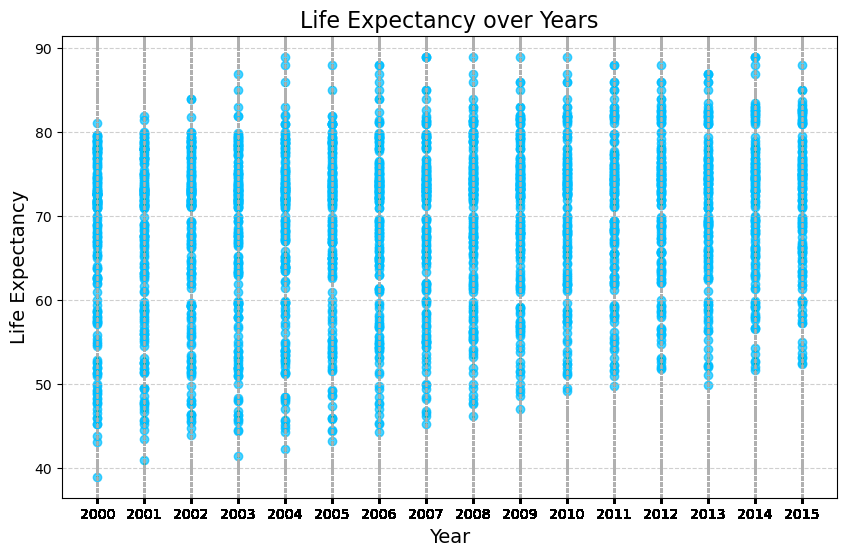

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Year'], df['Life expectancy'], color='deepskyblue', alpha=0.7)
plt.title('Life Expectancy over Years', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Life Expectancy', fontsize=14)
plt.xticks(df['Year'], fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

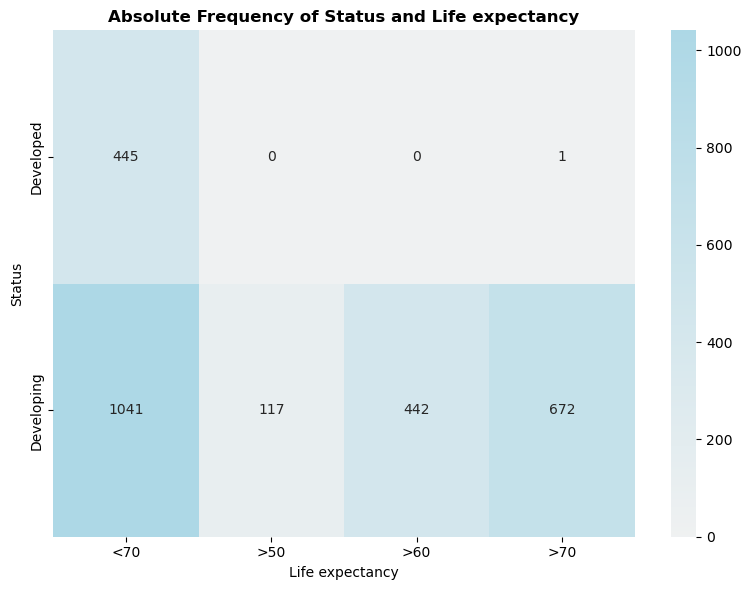

In [12]:
def depend(in_o, a, b, color):
    frequency_table = pd.crosstab(in_o[a], in_o[b])
    fig, ax1 = plt.subplots(1, 1, figsize=(8, 6)) 
    
    custom_palette_abs = sns.light_palette(color, as_cmap=True)
    sns.heatmap(frequency_table, cmap=custom_palette_abs, annot=True, fmt='g', ax=ax1)
    ax1.set_title(f'Absolute Frequency of {a} and {'Life expectancy'}', fontweight='bold')
    ax1.set_xlabel('Life expectancy')
    ax1.set_ylabel(a)
    
    plt.tight_layout()
    plt.show()

depend(df_analysis, 'Status', 'age_category', 'lightblue')

📝 From the graph it is clear that people from more developed countries live more than 70 years. While in less developed countries there is a greater variation

## *Analyze the different diseases*

📝 Let's analyze the different diseases that are given in the dataset (Hepatitis B, Measles, Polio, Diphtheria, HIV/AIDS)

In [16]:
def diseases(df, column, palette="deep"):
    # Remove missing values
    data = df[column].dropna()
    
    # Set style and color palette
    sns.set_theme(style="whitegrid", palette=palette)

    # Calculate statistics
    stats = {
        "Minimum Value": data.min(),
        "Maximum Value": data.max(),
        "Range": data.max() - data.min(),
        "Mean": data.mean(),
        "Median": data.median(),
        "Variance": data.var(),
    }
    stats_df = pd.DataFrame(list(stats.items()), columns=["Parameter", "Value"])
    display(stats_df)

    # Initialize figure layout
    fig = plt.figure(figsize=(12, 8))
    grid = gridspec.GridSpec(2, 2, figure=fig)


    # Boxplot
    ax2 = fig.add_subplot(grid[1, 0])
    sns.boxplot(y=data, ax=ax2, medianprops={"color": "black"})
    ax2.set_title("Boxplot")

    # Violin plot
    ax3 = fig.add_subplot(grid[1, 1])
    sns.violinplot(y=data, ax=ax3)
    ax3.set_title("Violin Plot")

    
    # Histogram
    ax1 = fig.add_subplot(grid[0, :])
    sns.histplot(data=data, bins=30, kde=False, ax=ax1)
    ax1.set_title("Histogram")

    # Display the plots
    plt.tight_layout()
    plt.show()

    # Reset style to default
    sns.reset_defaults()


,Parameter,Value
0,Minimum Value,2.000000
1,Maximum Value,99.000000
2,Range,97.000000
3,Mean,82.166358
4,Median,93.000000
5,Variance,573.008267


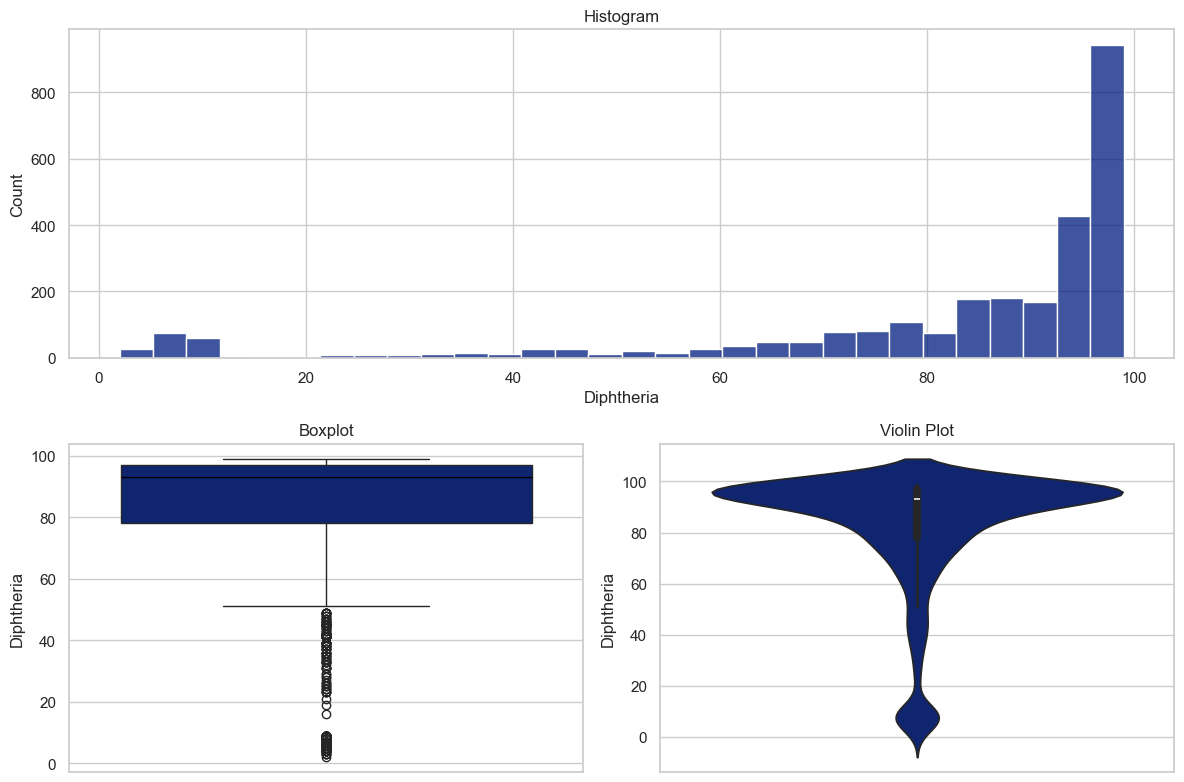

In [17]:
diseases(df, column='Diphtheria', palette="dark")

📝 From the graph and parameters it can be seen that the average values ​​are between 80-100 ⬆️

,Parameter,Value
0,Minimum Value,3.000000
1,Maximum Value,99.000000
2,Range,96.000000
3,Mean,82.564283
4,Median,93.000000
5,Variance,546.651444


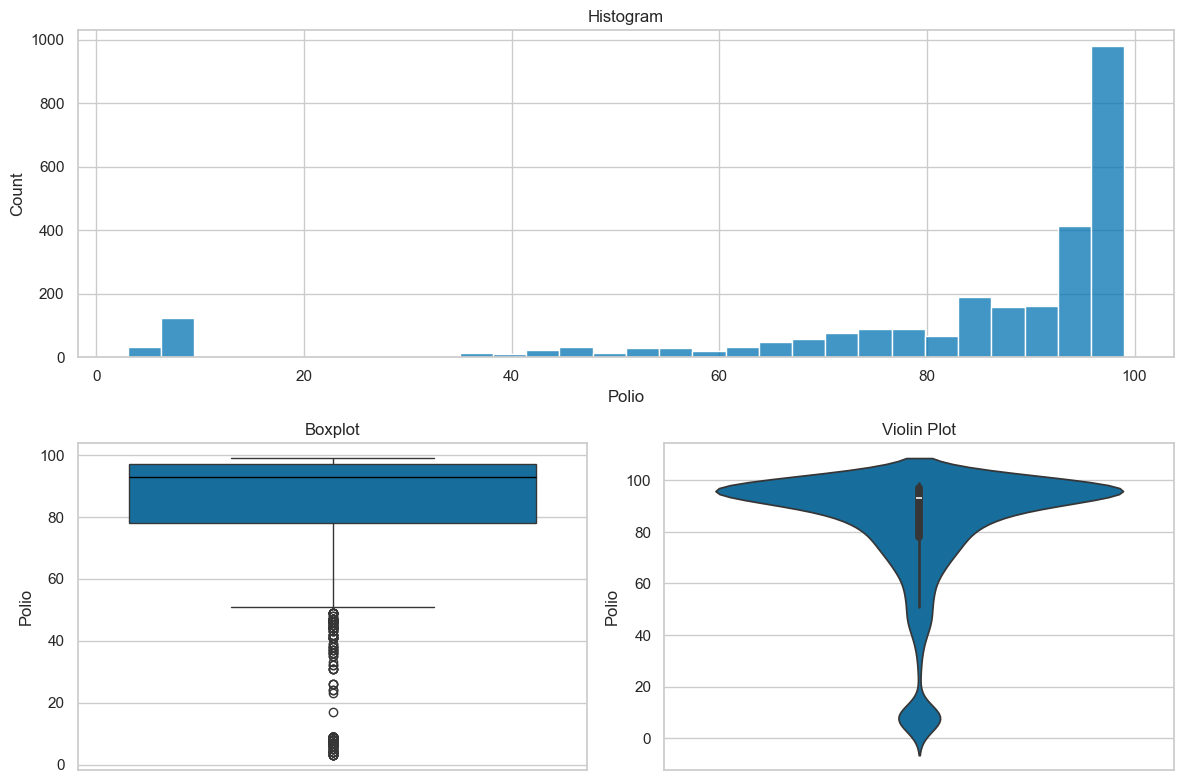

In [19]:
diseases(df, column='Polio', palette="colorblind")

📝 From the graph and parameters it can be seen that the average values ​​are between 80-100 ⬆️

,Parameter,Value
0,Minimum Value,1.000000
1,Maximum Value,99.000000
2,Range,98.000000
3,Mean,80.838592
4,Median,92.000000
5,Variance,638.278144


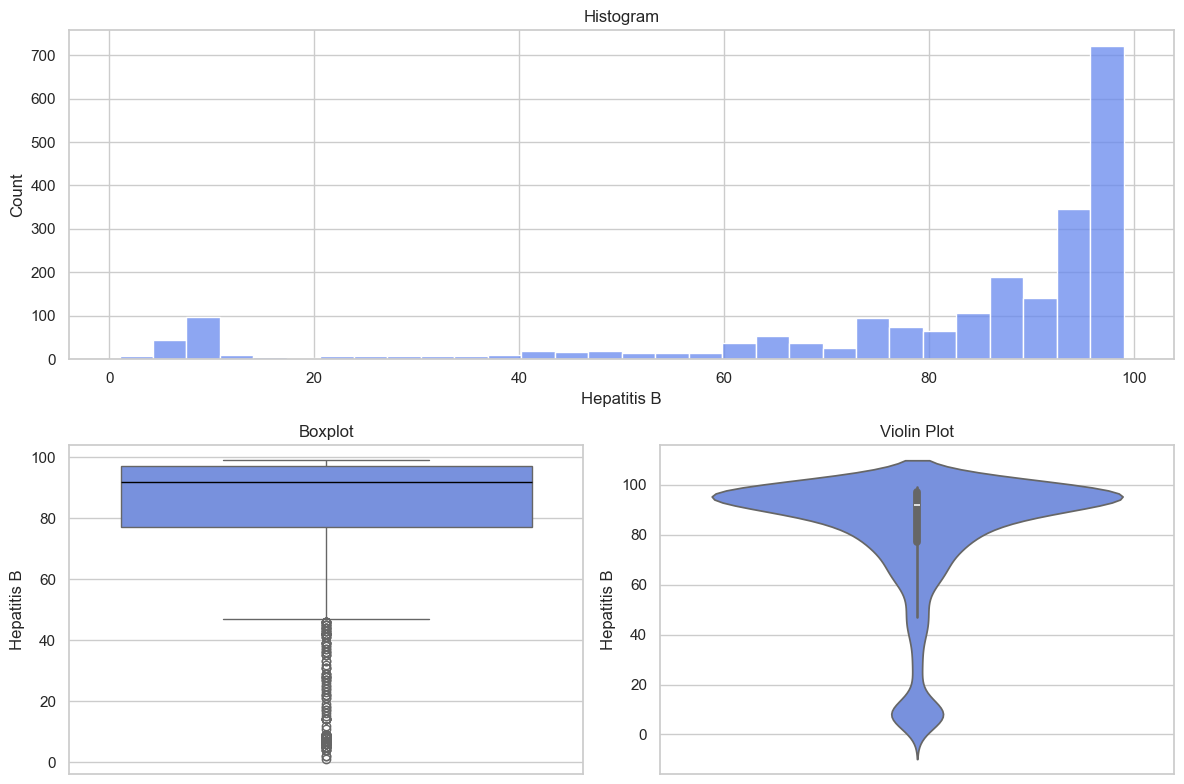

In [21]:
diseases(df, column='Hepatitis B', palette="coolwarm")

📝 From the graph and parameters it can be seen that the average values ​​are between 80-100 ⬆️

,Parameter,Value
0,Minimum Value,0.100000
1,Maximum Value,50.600000
2,Range,50.500000
3,Mean,1.826343
4,Median,0.100000
5,Variance,27.638879


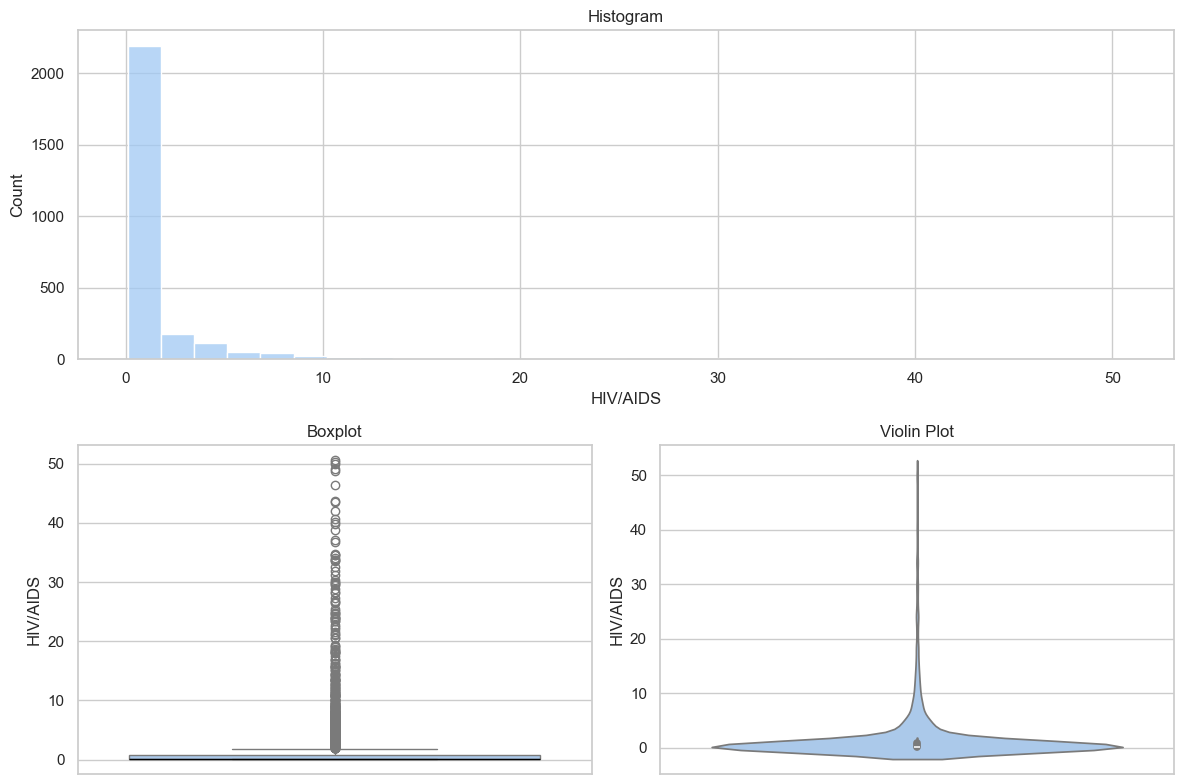

In [23]:
diseases(df, column='HIV/AIDS', palette="pastel")

📝 From the graph and parameters it can be seen that the average values ​​are between 0.1-5 ⬆️

 ## *Convert data* 🔄

📝Convert all other text flags to categorical + to their numerical equivalents.

In [27]:
print('-'*50)
display(df['Country'].value_counts())
print('-'*50)
display(df['Status'].value_counts())
print('-'*50)

--------------------------------------------------


Country
Afghanistan            16
Mozambique             16
Nepal                  16
New Zealand            16
Nicaragua              16
                       ..
Republic of Moldova    10
Samoa                  10
Croatia                10
Colombia               10
Lebanon                10
Name: count, Length: 183, dtype: int64

--------------------------------------------------


Status
Developing    2272
Developed      446
Name: count, dtype: int64

--------------------------------------------------


In [28]:
df['Status'] = df['Status'].astype('category').cat.codes

📝 I thought for a long time about what to do with country names, whether they are useful. There are more than 180 unique values ​​in the records, and there is already a record that indicates whether the country is developed or not. In the end, I decided to create a new feature that would indicate the continent on which the country is located.

📝 Now can remove the country flag

In [31]:
country_to_continent_updated = {
    'Afghanistan': 'Asia',
    'Albania': 'Europe',
    'Algeria': 'Africa',
    'Angola': 'Africa',
    'Antigua and Barbuda': 'North America',
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Azerbaijan': 'Asia',
    'Bahamas': 'North America',
    'Bahrain': 'Asia',
    'Bangladesh': 'Asia',
    'Barbados': 'North America',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Belize': 'North America',
    'Benin': 'Africa',
    'Bhutan': 'Asia',
    'Bolivia (Plurinational State of)': 'South America',
    'Bosnia and Herzegovina': 'Europe',
    'Botswana': 'Africa',
    'Brunei Darussalam': 'Asia',
    'Bulgaria': 'Europe',
    'Burkina Faso': 'Africa',
    'Burundi': 'Africa',
    'Cabo Verde': 'Africa',
    'Cambodia': 'Asia',
    'Cameroon': 'Africa',
    'Central African Republic': 'Africa',
    'Chad': 'Africa',
    'Chile': 'South America',
    'China': 'Asia',
    'Colombia': 'South America',
    'Comoros': 'Africa',
    'Congo': 'Africa',
    'Costa Rica': 'North America',
    'Croatia': 'Europe',
    'Cuba': 'North America',
    'Cyprus': 'Asia',
    'Czechia': 'Europe',
    "Côte d'Ivoire": 'Africa',
    "Democratic People's Republic of Korea": 'Asia',
    'Democratic Republic of the Congo': 'Africa',
    'Denmark': 'Europe',
    'Djibouti': 'Africa',
    'Dominican Republic': 'North America',
    'Ecuador': 'South America',
    'Egypt': 'Africa',
    'El Salvador': 'North America',
    'Equatorial Guinea': 'Africa',
    'Eritrea': 'Africa',
    'Estonia': 'Europe',
    'Eswatini': 'Africa',
    'Ethiopia': 'Africa',
    'Fiji': 'Oceania',
    'Finland': 'Europe',
    'France': 'Europe',
    'Gabon': 'Africa',
    'Gambia': 'Africa',
    'Georgia': 'Asia',
    'Germany': 'Europe',
    'Ghana': 'Africa',
    'Greece': 'Europe',
    'Grenada': 'North America',
    'Guatemala': 'North America',
    'Guinea': 'Africa',
    'Guinea-Bissau': 'Africa',
    'Guyana': 'South America',
    'Haiti': 'North America',
    'Honduras': 'North America',
    'Hungary': 'Europe',
    'Iceland': 'Europe',
    'India': 'Asia',
    'Indonesia': 'Asia',
    'Iran (Islamic Republic of)': 'Asia',
    'Iraq': 'Asia',
    'Ireland': 'Europe',
    'Israel': 'Asia',
    'Italy': 'Europe',
    'Jamaica': 'North America',
    'Japan': 'Asia',
    'Jordan': 'Asia',
    'Kazakhstan': 'Asia',
    'Kenya': 'Africa',
    'Kiribati': 'Oceania',
    'Kuwait': 'Asia',
    'Kyrgyzstan': 'Asia',
    "Lao People's Democratic Republic": 'Asia',
    'Latvia': 'Europe',
    'Lebanon': 'Asia',
    'Lesotho': 'Africa',
    'Liberia': 'Africa',
    'Libya': 'Africa',
    'Lithuania': 'Europe',
    'Luxembourg': 'Europe',
    'Madagascar': 'Africa',
    'Malawi': 'Africa',
    'Malaysia': 'Asia',
    'Maldives': 'Asia',
    'Mali': 'Africa',
    'Malta': 'Europe',
    'Marshall Islands': 'Oceania',
    'Mauritania': 'Africa',
    'Mauritius': 'Africa',
    'Mexico': 'North America',
    'Micronesia (Federated States of)': 'Oceania',
    'Moldova': 'Europe',
    'Monaco': 'Europe',
    'Mongolia': 'Asia',
    'Montenegro': 'Europe',
    'Morocco': 'Africa',
    'Mozambique': 'Africa',
    'Myanmar': 'Asia',
    'Namibia': 'Africa',
    'Nauru': 'Oceania',
    'Nepal': 'Asia',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Nicaragua': 'North America',
    'Niger': 'Africa',
    'Nigeria': 'Africa',
    'North Macedonia': 'Europe',
    'Norway': 'Europe',
    'Oman': 'Asia',
    'Pakistan': 'Asia',
    'Palau': 'Oceania',
    'Panama': 'North America',
    'Papua New Guinea': 'Oceania',
    'Paraguay': 'South America',
    'Peru': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Qatar': 'Asia',
    'Republic of Korea': 'Asia',
    'Romania': 'Europe',
    'Russian Federation': 'Europe',
    'Rwanda': 'Africa',
    'Saint Kitts and Nevis': 'North America',
    'Saint Lucia': 'North America',
    'Saint Vincent and the Grenadines': 'North America',
    'Samoa': 'Oceania',
    'San Marino': 'Europe',
    'Sao Tome and Principe': 'Africa',
    'Saudi Arabia': 'Asia',
    'Senegal': 'Africa',
    'Serbia': 'Europe',
    'Seychelles': 'Africa',
    'Sierra Leone': 'Africa',
    'Singapore': 'Asia',
    'Slovakia': 'Europe',
    'Slovenia': 'Europe',
    'Solomon Islands': 'Oceania',
    'Somalia': 'Africa',
    'South Africa': 'Africa',
    'South Sudan': 'Africa',
    'Spain': 'Europe',
    'Sri Lanka': 'Asia',
    'Sudan': 'Africa',
    'Suriname': 'South America',
    'Swaziland': 'Africa',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Syrian Arab Republic': 'Asia',
    'Tajikistan': 'Asia',
    'Thailand': 'Asia',
    'Timor-Leste': 'Asia',
    'Togo': 'Africa',
    'Tonga': 'Oceania',
    'Trinidad and Tobago': 'North America',
    'Tunisia': 'Africa',
    'Turkey': 'Asia',
    'Turkmenistan': 'Asia',
    'Tuvalu': 'Oceania',
    'Uganda': 'Africa',
    'Ukraine': 'Europe',
    'United Arab Emirates': 'Asia',
    'United Kingdom': 'Europe',
    'United States': 'North America',
    'Uruguay': 'South America',
    'Uzbekistan': 'Asia',
    'Vanuatu': 'Oceania',
    'Venezuela (Bolivarian Republic of)': 'South America',
    'Viet Nam': 'Asia',
    'Yemen': 'Asia',
    'Zambia': 'Africa',
    'Zimbabwe': 'Africa',
    'Brazil': 'South America',
    'Canada': 'North America',
    'The former Yugoslav republic of Macedonia': 'Europe', 
    'United Kingdom of Great Britain and Northern Ireland': 'Europe',  
    'United Republic of Tanzania': 'Africa',
    'Republic of Moldova': 'Europe', 
    'United States of America': 'North America'
}
df['Continent'] = df['Country'].map(country_to_continent_updated)

df['Continent'] = df['Continent'].fillna('Unknown')

print(df[['Country', 'Continent']].head())


       Country Continent
0  Afghanistan      Asia
1  Afghanistan      Asia
2  Afghanistan      Asia
3  Afghanistan      Asia
4  Afghanistan      Asia


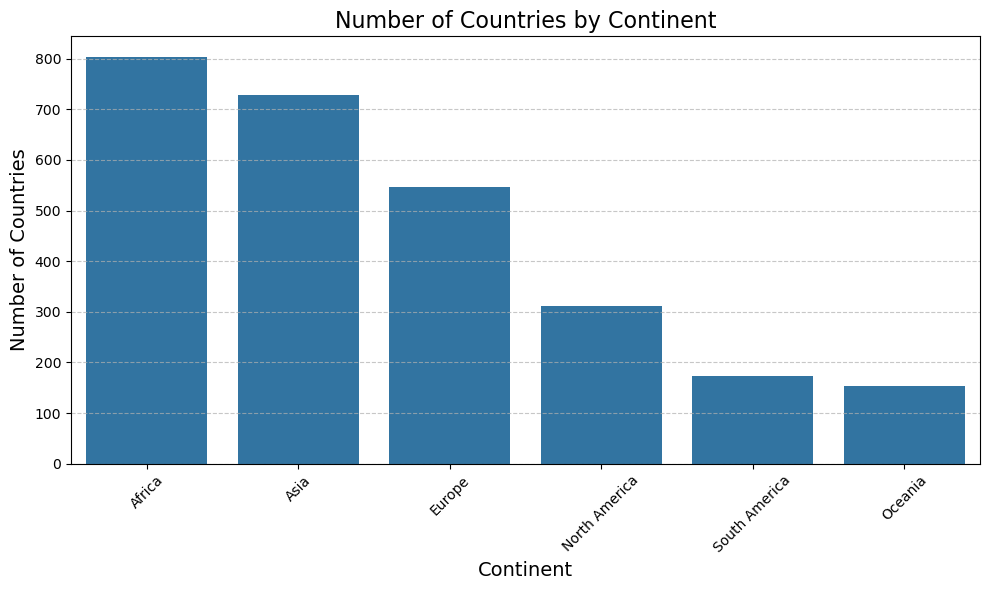

In [32]:
continent_counts = df['Continent'].value_counts()

continent_data = continent_counts.reset_index()
continent_data.columns = ['Continent', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=continent_data, x='Continent', y='Count')

plt.title("Number of Countries by Continent", fontsize=16)
plt.xlabel("Continent", fontsize=14)
plt.ylabel("Number of Countries", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

📝 African countries are the most re presented in the dataset

In [34]:
df.drop(columns=["Country"], inplace=True)

In [35]:
df['Continent'].value_counts()

Continent
Africa           804
Asia             728
Europe           546
North America    312
South America    174
Oceania          154
Name: count, dtype: int64

📝 In the case of continents we have a small number of elements (6), so one-hot-encoding can be used

In [37]:
df = pd.get_dummies(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2718 entries, 0 to 2717
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             2718 non-null   int64  
 1   Status                           2718 non-null   int8   
 2   Life expectancy                  2718 non-null   float64
 3   Adult Mortality                  2718 non-null   float64
 4   infant deaths                    2718 non-null   int64  
 5   Alcohol                          2558 non-null   float64
 6   percentage expenditure           2718 non-null   float64
 7   Hepatitis B                      2187 non-null   float64
 8   Measles                          2718 non-null   int64  
 9   BMI                              2686 non-null   float64
 10  under-five deaths                2718 non-null   int64  
 11  Polio                            2699 non-null   float64
 12  Total expenditure   

📝  To avoid leaks, I will work separately with the validation/test/training parts. First, I will prepare the data for the Linear and Ridge Regression models.

In [39]:
df_reg = df.copy()

In [40]:
def splitting(df, target_column='Life expectancy', test_size=0.4, val_test_split=0.5):
    # Split the training dataset into 60% train and 40% rest
    Xtrain, Xrest, ytrain, yrest = train_test_split(
        df.drop(columns=[target_column]), 
        df[target_column], 
        test_size=test_size, 
        random_state=random_seed
    )

    # Split the rest of the data into 20% validation and 20% test
    Xval, Xtest, yval, ytest = train_test_split(
        Xrest, 
        yrest, 
        test_size=val_test_split, 
        random_state=random_seed
    )
    
    # Return all data splits
    return Xtrain, Xval, Xtest, ytrain, yval, ytest

Xtrain_reg, Xval_reg, Xtest_reg, ytrain_reg, yval_reg, ytest_reg = splitting(df_reg)

In [41]:
print(f"Train size, X: {Xtrain_reg.shape}, y: {ytrain_reg.shape}")
print(f"Val size, X: {Xval_reg.shape}, y: {yval_reg.shape}")
print(f"Test size, X: {Xtest_reg.shape}, y: {ytest_reg.shape}")

Train size, X: (1630, 26), y: (1630,)
Val size, X: (544, 26), y: (544,)
Test size, X: (544, 26), y: (544,)


## *Ridge Regression* 

📝 To avoid outliers and for a more stable model I chose to fill the gaps with the median

In [46]:
median_values = Xtrain_reg.median()

Xtrain_reg = Xtrain_reg.fillna(median_values)
Xval_reg = Xval_reg.fillna(median_values)
Xtest_reg = Xtest_reg.fillna(median_values)

📝 Ridge Regression is a good choice for life expectancy prediction problems because it allows for complex relationships between features and reduces the risk of overfitting.

In [48]:
scaler = StandardScaler().fit(Xtrain_reg) #StandardScaler() is better then MinMax()
#scaler = MinMax().fit(Xtrain_reg)


Xtrain_sc = scaler.transform(Xtrain_reg)
Xval_sc = scaler.transform(Xval_reg)
Xtest_sc = scaler.transform(Xtest_reg)


📝 Certain attributes show a high degree of correlation with one another. For instance, if the correlation between "Schooling" and "Income composition of resources" is strong, it may suggest that a country's education level is closely tied to its economic development.

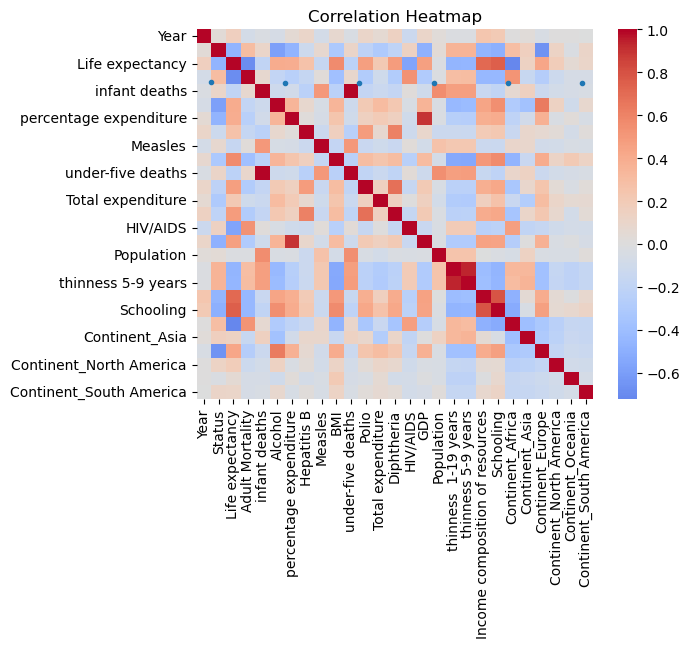

Optimal alpha  message: Solution found.
 success: True
  status: 0
     fun: 3.8664768350876844
       x: 0.2417066000290998
     nit: 21
    nfev: 21




In [49]:
#the code was taken from 08_ridge_regression
from scipy import optimize

def get_opt_ridge_model(Xtrain, Xval):
    def ridgemodel_eval(alpha):
        clf = Ridge(alpha=alpha)
        clf.fit(Xtrain, ytrain_reg)
        return root_mean_squared_error(yval_reg, clf.predict(Xval))

    alphas = np.linspace(1,500,100)
    alphas_res = [ridgemodel_eval(alpha) for alpha in alphas]
    plt.plot(alphas, alphas_res, '.')
    plt.show()

    opt_alpha = optimize.minimize_scalar(ridgemodel_eval, options = {'maxiter': 30}, method = 'bounded', bounds=(0.1, 400))
    print('Optimal alpha', opt_alpha)
    print("\n")

    clf_opt_ridge = Ridge(alpha = opt_alpha.x)
    clf_opt_ridge.fit(Xtrain, ytrain_reg)
    return clf_opt_ridge
clf_opt_ridge = get_opt_ridge_model(Xtrain_sc, Xval_sc)

In [43]:
df_corr = df.copy()
plt.title('Correlation Heatmap') 
string_columns = df_corr.select_dtypes(include='object').columns
df_corr[string_columns] = df_corr[string_columns].astype('category').apply(lambda col: col.cat.codes)

sns.heatmap(df_corr.corr(), center=0, cmap='coolwarm')


<Axes: title={'center': 'Correlation Heatmap'}>

📝 These results are not bad for our task, but I think other modes can predict better.

In [51]:
RMSE_val_opt_ridge = root_mean_squared_error(yval_reg, clf_opt_ridge.predict(Xval_sc))
print(f'RMSE (val): {RMSE_val_opt_ridge:.5f}')
MAE =  mean_absolute_error(yval_reg, clf_opt_ridge.predict(Xval_sc))
print(f'MAE (val): {MAE:.5f}')

RMSE (val): 3.86648
MAE (val): 2.92769


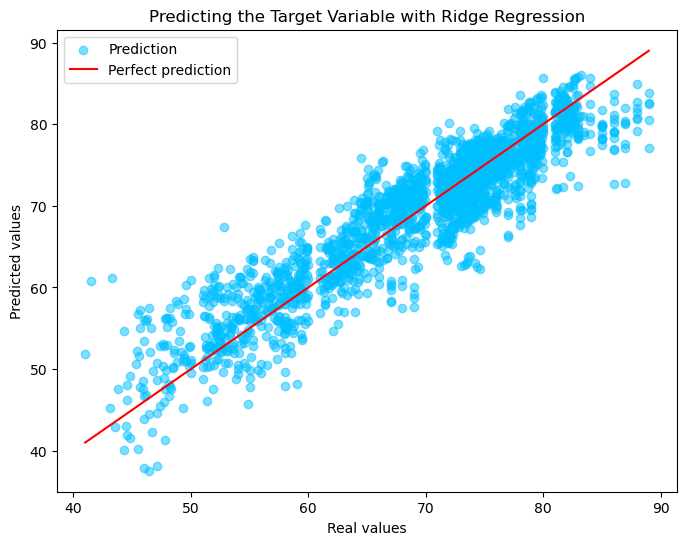

In [52]:
y_pred_train = clf_opt_ridge.predict(Xtrain_sc)
y_pred_val = clf_opt_ridge.predict(Xval_sc)
X_total = np.concatenate([Xtrain_sc, Xval_sc])
y_total = np.concatenate([ytrain_reg, yval_reg])
y_pred_total = np.concatenate([y_pred_train, y_pred_val])

plt.figure(figsize=(8, 6))
plt.scatter(y_total, y_pred_total, label="Prediction", color="deepskyblue", alpha=0.5)
plt.plot([y_total.min(), y_total.max()], [y_total.min(), y_total.max()], color='red', label="Perfect prediction")
plt.xlabel("Real values")
plt.ylabel("Predicted values")
plt.legend()
plt.title("Predicting the Target Variable with Ridge Regression")
plt.show()

📝 Overall, after optimization, the model showed not the worst results, however, they are not good enough, from the graph it is clear that sometimes the model predicts values ​​that are very different from the correct ones.

## *Random Forest*

📝 Random Forest is suitable for predicting life expectancy because it is good at identifying complex nonlinear relationships between social, economic, and medical factors. It is robust to noise in the data and automatically determines which features are most important for prediction.

In [56]:
df_forest = df.copy()
Xtrain_forest, Xval_forest, Xtest_forest, ytrain_forest, yval_forest, ytest_forest = splitting(df_forest)

In [57]:
median_values = Xtrain_forest.median()

Xtrain_forest = Xtrain_forest.fillna(median_values)
Xval_forest = Xval_forest.fillna(median_values)
Xtest_forest = Xtest_forest.fillna(median_values)

In [58]:
class CustomRandomForest:
    def __init__(self, n_estimators, max_samples, max_depth, **kwargs):
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_depth = max_depth
        self.kwargs = kwargs
        self.forest = []

    def fit(self, X, y):
        self.forest = []
        n_samples = X.shape[0]

        if isinstance(self.max_samples, float):  
            sample_size = int(n_samples * self.max_samples)
        else:  
            sample_size = min(self.max_samples, n_samples)

        for _ in range(self.n_estimators):
            X_bootstrap, y_bootstrap = resample(X, y, replace=True, n_samples=sample_size)
            tree = DecisionTreeRegressor(max_depth=self.max_depth, **self.kwargs)
            tree.fit(X_bootstrap, y_bootstrap)
            self.forest.append(tree)

    def predict(self, X):
        predictions = [tree.predict(X) for tree in self.forest]
        return np.mean(predictions, axis=0)

    def get_params(self, deep=True):
        return {
            'n_estimators': self.n_estimators,
            'max_samples': self.max_samples,
            'max_depth': self.max_depth,
            **self.kwargs
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


📝 In order to get a more stable and high-quality model when searching for parameters, I used cross-validation

In [60]:
# Grid Search with Cross-Validation
param_grid = {
    'n_estimators': list(range(10, 150, 10)), 
    'max_depth': list(range(5, 25, 5)),
    'max_samples': [0.5, 0.75, 1.0],  
}

min_rmse = float('inf')
min_mae = float('inf')
param_comb = list(ParameterGrid(param_grid))

results = []

for params in param_comb:
    les = CustomRandomForest(**params)

    rmse_scores = cross_val_score(les, Xtrain_forest, ytrain_forest, 
                                  scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
    mae_scores = cross_val_score(les, Xtrain_forest, ytrain_forest, 
                                 scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

    mean_rmse = -np.mean(rmse_scores)
    mean_mae = -np.mean(mae_scores)

    results.append((params, mean_rmse, mean_mae))

    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
        min_mae = mean_mae
        top_params = params

print(f"Best Random Forest parameters: {top_params}")
print(f"Top RMSE: {min_rmse}")
print(f"Top MAE: {min_mae}")


Best Random Forest parameters: {'max_depth': 20, 'max_samples': 1.0, 'n_estimators': 100}
Top RMSE: 2.0584943747132045
Top MAE: 1.3303039969513255


In [61]:
best_model = CustomRandomForest(**top_params)
best_model.fit(Xtrain_forest, ytrain_forest)


# Predict on train set
y_pred_train = best_model.predict(Xtrain_forest)

# Evaluate on train set
rmse_train = root_mean_squared_error(ytrain_forest, y_pred_train)
mae_train = mean_absolute_error(ytrain_forest, y_pred_train)

print("\nEvaluation on Train Set:")
print(f"Train RMSE: {rmse_train}")
print(f"Train MAE: {mae_train}")

#Predict on val set
y_pred_val = best_model.predict(Xval_forest)

# Evaluate on val set
rmse_val = root_mean_squared_error(yval_forest, y_pred_val)
mae_val = mean_absolute_error(yval_forest, y_pred_val)

print("\nEvaluation on Val Set:")
print(f"Val RMSE: {rmse_val}")
print(f"Val MAE: {mae_val}")


Evaluation on Train Set:
Train RMSE: 0.7410305172338484
Train MAE: 0.4603411263918802

Evaluation on Val Set:
Val RMSE: 1.8942594760482927
Val MAE: 1.2259339928546014


📝 For greater clarity, I visualized the accuracy of the model depending on the hyperparameters.

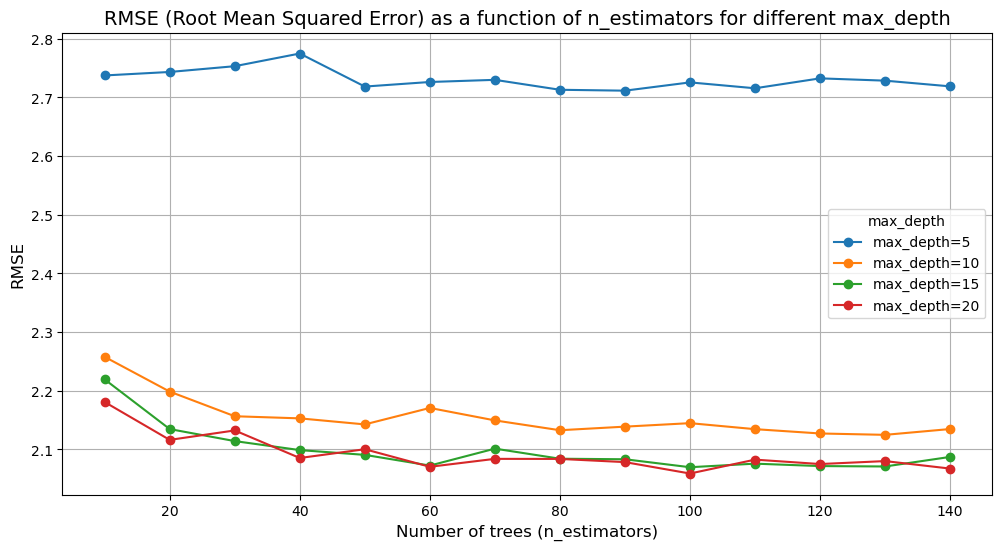

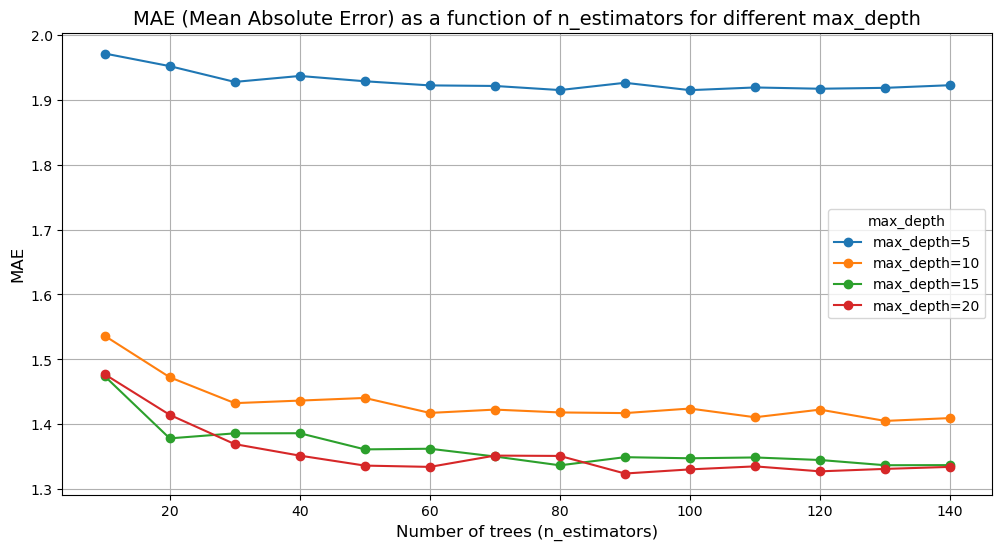

In [63]:
# Collecting data for graphs from results
rmse_values = {depth: [None] * len(param_grid['n_estimators']) for depth in param_grid['max_depth']}
mae_values = {depth: [None] * len(param_grid['n_estimators']) for depth in param_grid['max_depth']}

for params, mean_rmse, mean_mae in results:
    depth = params['max_depth']
    n_index = param_grid['n_estimators'].index(params['n_estimators'])

    rmse_values[depth][n_index] = mean_rmse
    mae_values[depth][n_index] = mean_mae
    
# RMSE Visualization
plt.figure(figsize=(12, 6))
for depth, values in rmse_values.items():
    plt.plot(param_grid['n_estimators'], values, label=f'max_depth={depth}', marker='o')

plt.title('RMSE (Root Mean Squared Error) as a function of n_estimators for different max_depth', fontsize=14)
plt.xlabel('Number of trees (n_estimators)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend(title='max_depth', fontsize=10)
plt.grid(True)
plt.show()

# MAE Visualization
plt.figure(figsize=(12, 6))
for depth, values in mae_values.items():
    plt.plot(param_grid['n_estimators'], values, label=f'max_depth={depth}', marker='o')

plt.title('MAE (Mean Absolute Error) as a function of n_estimators for different max_depth', fontsize=14)
plt.xlabel('Number of trees (n_estimators)', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.legend(title='max_depth', fontsize=10)
plt.grid(True)
plt.show()


📝 From the graph it is clear that the values ​​are most optimal at a depth of 15.

## *kNN*

📝 KNN (k-nearest neighbors) can be used to predict life expectancy because it relies on similarity between objects. This is useful if countries or regions with similar socioeconomic and health indicators have similar life expectancy. The method is easy to implement and is suitable for data with local dependencies.

In [77]:
scaler = StandardScaler() #stansard scaler shows best metrics
#scaler = MinMaxScaler()

In [79]:
df_kNN = df.copy()

Xtrain_kNN, Xval_kNN, Xtest_kNN, ytrain_kNN, yval_kNN, ytest_kNN = splitting(df_kNN)

median_values = Xtrain_kNN.median()
Xtrain_kNN = Xtrain_kNN.fillna(median_values)
Xval_kNN = Xval_kNN.fillna(median_values)
Xtest_kNN = Xtest_kNN.fillna(median_values)

Xtrain_kNN = pd.DataFrame(scaler.fit_transform(Xtrain_kNN), columns=Xtrain_kNN.columns)
Xval_kNN = pd.DataFrame(scaler.transform(Xval_kNN), columns=Xval_kNN.columns)
Xtest_kNN = pd.DataFrame(scaler.transform(Xtest_kNN), columns=Xtest_kNN.columns)

In [81]:
param_grid = {
    "n_neighbors": range(1, 15),
    "metric": ["euclidean", "manhattan", "chebyshev", "minkowski"],
}
param_comb = ParameterGrid(param_grid)

val_metric = []

for params in param_comb:
    regK1 = KNeighborsRegressor(**params)
    fold_rmse = cross_val_score(regK1, Xtrain_kNN, ytrain_kNN, cv=5, scoring='neg_root_mean_squared_error')
    val_metric.append(-np.mean(fold_rmse))  

best_knn_params = param_comb[np.argmin(val_metric)]
best_knn_metric = min(val_metric)
print(f"Best knn_params: {best_knn_params} with cross-validation RMSE {best_knn_metric:.4f}.")

regK = KNeighborsRegressor(**best_knn_params)
regK.fit(Xtrain_kNN, ytrain_kNN)

val_score = metrics.root_mean_squared_error(yval_kNN, regK.predict(Xval_kNN))
train_score = metrics.root_mean_squared_error(ytrain_kNN, regK.predict(Xtrain_kNN))
print('RMSE score (val): {0:.6f}'.format(val_score))
print('RMSE score (train): {0:.6f}'.format(train_score))

val_score = metrics.mean_absolute_error(yval_kNN, regK.predict(Xval_kNN))
train_score = metrics.mean_absolute_error(ytrain_kNN, regK.predict(Xtrain_kNN))
print('MAE score (val): {0:.6f}'.format(val_score))
print('MAE score (train): {0:.6f}'.format(train_score))

Best knn_params: {'n_neighbors': 2, 'metric': 'manhattan'} with cross-validation RMSE 2.4774.
RMSE score (val): 2.265748
RMSE score (train): 1.309402
MAE score (val): 1.409375
MAE score (train): 0.736564


In [82]:
metrics.mean_absolute_error(ytest_kNN, regK.predict(Xtest_kNN))
metrics.root_mean_squared_error(ytest_kNN, regK.predict(Xtest_kNN))

2.27512826884681

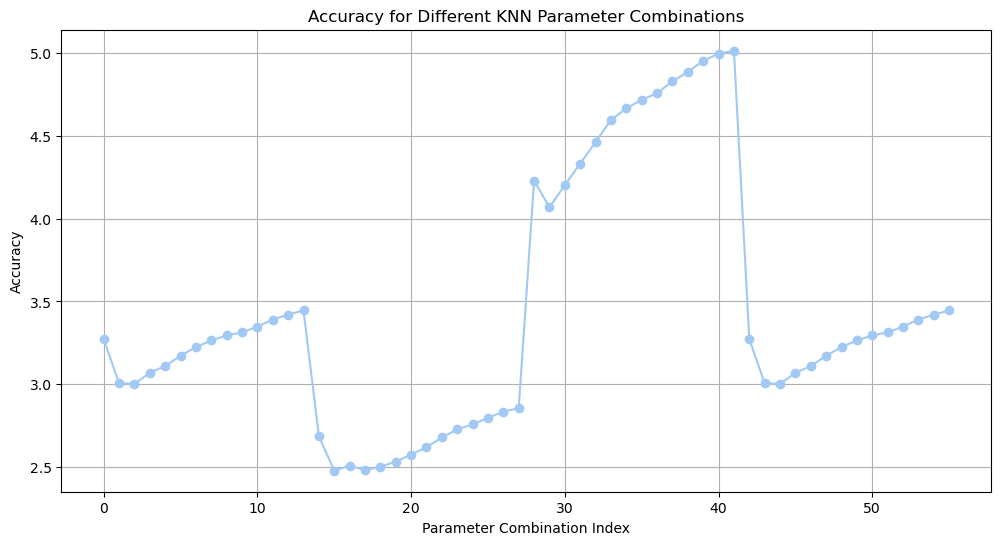

In [122]:
param_grid = {
    "n_neighbors": range(1, 15),
    "metric": ["euclidean", "manhattan", "chebyshev", "minkowski"],
}
param_comb = list(range(len(val_metric))) 

plt.figure(figsize=(12, 6))
plt.plot(param_comb, val_metric, marker='o', linestyle='-', color='b')
plt.xlabel("Parameter Combination Index")
plt.ylabel("Accuracy")
plt.title("Accuracy for Different KNN Parameter Combinations")
plt.grid(True)
plt.show()


📝 Let's look at what our model looks like depending on the dimension

In [85]:
min_dist_ratio = []
max_dist_ratio = []
mean_dist_ratio = []
for n in range(1, 80 + 1):
    model = KNeighborsRegressor(n_neighbors=4, p=1)
    model.fit(Xtrain_kNN.iloc[:, 0:n], ytrain_kNN)
    dist, nn = model.kneighbors(Xval_kNN.iloc[:, 0:n])
    min_dist_ratio.append(np.mean(np.min(dist, axis=1)) / math.sqrt(n))
    max_dist_ratio.append(np.mean(np.max(dist, axis=1)) / math.sqrt(n))
    mean_dist_ratio.append(np.mean(np.mean(dist, axis=1)) / math.sqrt(n))

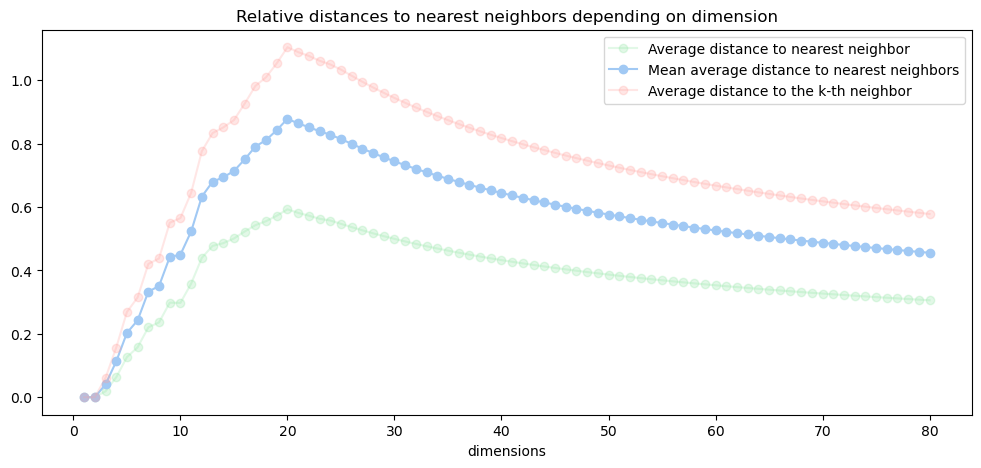

In [86]:
plt.figure(figsize=(12,5))
plt.xlabel('dimensions')
plt.plot(range(1, len(min_dist_ratio) + 1), min_dist_ratio, 'go-', alpha=0.25, label='Average distance to nearest neighbor')
plt.plot(range(1, len(mean_dist_ratio) + 1), mean_dist_ratio, 'bo-', label='Mean average distance to nearest neighbors')
plt.plot(range(1, len(max_dist_ratio) + 1), max_dist_ratio, 'ro-', alpha=0.25, label='Average distance to the k-th neighbor')
plt.title("Relative distances to nearest neighbors depending on dimension")
plt.legend()
plt.show()

## *Final model🏁*

Best Random Forest parameters: {'max_depth': 20, 'max_samples': 1.0, 'n_estimators': 100}
* Top RMSE: 2.0584943747132045
* Top MAE: 1.3303039969513255

Evaluation on Train Set:
* Train RMSE: 0.7605502894107813
* Train MAE: 0.4890173957332548

Evaluation on Val Set:
* Val RMSE: 1.9055433746952342
* Val MAE: 1.2481403999421616

For the final model, I chose random forest. The accuracy I got with knn and random forest is comparable, but Random Forest is often a more reliable choice because it is:
* More robust to noise and outliers,
* More efficient on large data,
* Less sensitive to parameters

In [95]:
# Predict on test set
y_pred_test = best_model.predict(Xtest_forest)

# Evaluate on test set
rmse_test = root_mean_squared_error(ytest_forest, y_pred_test)
mae_test = mean_absolute_error(ytest_forest, y_pred_test)

print("\nEvaluation on Test Set:")
print(f"Test RMSE: {rmse_test}")
print(f"Test MAE: {mae_test}")


Evaluation on Test Set:
Test RMSE: 1.782484080409967
Test MAE: 1.1497529840082057


📝 Despite the fact that I used cross-validation when building the model, it shows signs of overfitting (the difference between the predictions on the test dataset and the valid one is quite large), but the model shows good results on the valid and test datasets, from which I can conclude that the error on the new data will be about **1.9 - 2.3**

In [98]:
eval = pd.read_csv("/Users/cory/bi-ml1-2024-kimanna3/02/evaluation.csv")
countries = eval['Country']
years = eval['Year']
eval

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Albania,2015,Developing,74.0,0,4.60,364.975229,99.0,0,58.0,...,99.0,6.00,99.0,0.1,3954.227830,28873.0,1.2,1.3,0.762,14.2
1,Albania,2014,Developing,8.0,0,4.51,428.749067,98.0,0,57.2,...,98.0,5.88,98.0,0.1,4575.763787,288914.0,1.2,1.3,0.761,14.2
2,Albania,2013,Developing,84.0,0,4.76,430.876979,99.0,0,56.5,...,99.0,5.66,99.0,0.1,4414.723140,289592.0,1.3,1.4,0.759,14.2
3,Albania,2012,Developing,86.0,0,5.14,412.443356,99.0,9,55.8,...,99.0,5.59,99.0,0.1,4247.614380,2941.0,1.3,1.4,0.752,14.2
4,Albania,2011,Developing,88.0,0,5.37,437.062100,99.0,28,55.1,...,99.0,5.71,99.0,0.1,4437.178680,295195.0,1.4,1.5,0.738,13.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,Zambia,2014,Developing,314.0,28,0.01,196.667577,86.0,9,22.8,...,78.0,4.99,86.0,4.3,1738.882200,1562974.0,6.3,6.2,0.570,12.5
206,Zambia,2013,Developing,328.0,29,2.41,20.623063,79.0,35,22.3,...,74.0,4.99,79.0,4.8,185.793359,1515321.0,6.4,6.2,0.565,12.5
207,Zambia,2012,Developing,349.0,29,2.59,196.915250,78.0,896,21.7,...,7.0,4.91,78.0,5.6,1734.936120,14699937.0,6.5,6.3,0.554,12.3
208,Zambia,2011,Developing,366.0,29,2.57,183.046169,81.0,13234,21.2,...,83.0,4.26,81.0,6.3,1644.619672,14264756.0,6.6,6.4,0.543,12.0


In [100]:
eval['Status'] = eval['Status'].astype('category').cat.codes
eval['Continent'] = eval['Country'].map(country_to_continent_updated)
eval['Continent'] = eval['Continent'].fillna('Unknown')

print(eval[['Country', 'Continent']].head())

   Country Continent
0  Albania    Europe
1  Albania    Europe
2  Albania    Europe
3  Albania    Europe
4  Albania    Europe


In [102]:
eval.drop(columns=["Country"], inplace=True)

In [104]:
eval = pd.get_dummies(eval)

In [106]:
eval =  eval.fillna(median_values) #medain train

In [108]:
# predict life expectancy
predicted_life_expectancy = best_model.predict(eval)

# сreate a DataFrame with the results
results = pd.DataFrame({
    'Country': countries,
    'Year': years,
    'Life expectancy': predicted_life_expectancy
})

In [110]:
results.to_csv('results.csv', index=False)
import os
print(os.getcwd())

/Users/cory/bi-ml1-2024-kimanna3/02


In [112]:
results

,Country,Year,Life expectancy
0,Albania,2015,76.615492
1,Albania,2014,75.969492
2,Albania,2013,76.473409
3,Albania,2012,76.354409
4,Albania,2011,76.117409
...,...,...,...
205,Zambia,2014,60.855000
206,Zambia,2013,59.739000
207,Zambia,2012,56.870000
208,Zambia,2011,57.216000
